In [1]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)
from jax import numpy as np
import os


from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer, batch_exposures
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/numb/lib/python3.12/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/WR137/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/WR137/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/WR137/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "all_cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M_192.0', 'F380M_189.8', 'F380M_162.7', 'F480M_192.0', 'F480M_189.8', 'F480M_162.7'])


In [3]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]

ois = ois[4:]
# ois = ois[1:3] + ois[4:]
# ois = ois[-1:]

init_dist = np.ones((51, 51))
model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution=init_dist,
    # distribution=np.ones((121, 121)),
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=3.0,
)

# Initialise at the mean dirty image
otf = np.load("files/otf_support.npy")

params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
for filt in ["F380M", "F480M"]:
    dirty_imgs = [
        oi.dirty_image(model, rotate=True, otf_support=otf)
        for oi in ois
        if oi.filter == filt
    ]

    if dirty_imgs == []:
        print(f"No dirty images for filter {filt}, skipping initialisation.")
        continue
    mean_dirty = hypot(dirty_imgs)
    init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-16)
    for oi in ois:
        if oi.filter == filt:
            params["log_dist"][oi.get_key("log_dist")] = init_dist

model = model.set("params", params)

No dirty images for filter F380M, skipping initialisation.


In [4]:
# fig, ax = plt.subplots(1, 2, figsize=(5, 2))

# for idx, filt in enumerate(["F380M", "F480M"]):

#     init_dist = 10 ** model.params["log_dist"][filt]

#     c0 = dorito.plotting.plot_result(
#         ax[idx],
#         init_dist,
#         pixel_scale=dlu.rad2arcsec(model.pscale_in),
#         cmap="afmhot_10u",
#     )
#     fig.colorbar(c0, ax=ax[idx])
#     ax[idx].set(title=filt)

# plt.tight_layout()
# plt.show()

In [5]:
import time
from tqdm.notebook import tqdm
from amigo.fitting import (
    Trainer,
    ModelParams,
    get_optimiser,
    get_val_grad_fn,
    get_norm_loss_fn,
    get_update_fn,
    populate_lr_model,
    ParamHistory,
)


class Train(Trainer):

    def train(
        self,
        model,
        optimisers,
        epochs,
        batches: dict,
        args={},
    ):
        # Ensure args key exists and is the right type
        args = self.check_args_key(args)

        # Get the batches and raw exposures
        batches, exposures = self.unwrap_batches(batches)

        # Get the model parameters
        model_params = ModelParams({p: model.get(p) for p in optimisers.keys()})
        lrs = populate_lr_model(self.fishers, exposures, model_params)

        # Get the optax optimiser and history bits
        optim, state = get_optimiser(model_params, optimisers)
        history = ParamHistory(model_params)

        # Get the loss and update functions
        val_grad_fn = get_val_grad_fn(self.loss_fn)
        loss_fn = get_norm_loss_fn(val_grad_fn, self.grad_fn)
        update_fn = get_update_fn(optim, self.norm_fn)

        # Looping things
        t0 = time.time()
        looper = tqdm(range(0, epochs))
        loss_dict = dict([(key, []) for key in batches.keys()])
        aux_dict = {}

        # Loop
        for epoch in looper:
            if epoch == 1:
                t1 = time.time()

            if self.args_fn is not None:
                model, args = self.args_fn(model, args, epoch)

            # Create an empty gradient model to append gradients to
            grads = model_params.map(lambda x: x * 0.0)

            # Loop over randomised batch order
            for batch_key, batch in batches.items():
                # Calculate the loss and gradients
                loss, new_grads, args, aux = loss_fn(
                    model_params, lrs, model, batch, args
                )
                grads += new_grads

                # Append the mean batch loss to the loss dictionary and update aux dict
                loss_dict[batch_key].append(loss / len(batch))

                #
                if self.aux_fn is not None:
                    aux_dict = self.aux_fn(aux_dict, aux)

                # Check for NaNs and exit if so
                if np.isnan(loss):
                    print(f"Loss is NaN on epoch {epoch}, exiting fit")
                    return self.finalise(
                        t0,
                        model,
                        loss_dict,
                        aux,
                        model_params,
                        history,
                        lrs,
                        epochs,
                        False,
                    )

                # args["loss"] = loss

            # Update the regular parameters and append to history
            model_params, state, args = update_fn(grads, model_params, state, args)
            history = history.append(model_params)

            # Update the looper
            loop_fn = self.default_looper if self.looper_fn is None else self.looper_fn
            loop_fn(looper, loss_dict)

            # Print helpful things run time
            if epoch == 0:
                self.initial_print(loss_dict)
            if epoch == 1:
                self.second_print(t1, epochs)

        # Print the runtime stats and return Result object
        return self.finalise(
            t0, model, loss_dict, aux, model_params, history, lrs, epochs, True
        )

In [6]:
# import jax.scipy as jsp
import jax.random as jr


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            dist = 10**log_dist

            # # setting edges values to zero to avoid edge effects
            # n = 10
            # dist = dist.at[-n:, :].set(1e-16)
            # dist = dist.at[:, -n:].set(1e-16)
            # dist = dist.at[:n, :].set(1e-16)
            # dist = dist.at[:, :n].set(1e-16)

            # normalising the distribution
            params["log_dist"][k] = np.log10(dist / dist.sum())

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def phase_centre(model, oi):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def COM(arr):
    h, w = arr.shape
    y = np.arange(h)
    x = np.arange(w)
    yy, xx = np.meshgrid(y, x, indexing="ij")  # Shape (h, w)

    total_mass = np.sum(arr)
    com_y = np.sum(yy * arr) / total_mass
    com_x = np.sum(xx * arr) / total_mass

    return np.array([com_y, com_x])


def centre_of_mass(model, oi):
    distribution = model.get_distribution(oi)
    return COM(distribution)


O = COM(init_dist)
print("Initial Centroid (y, x):", O)


def centered_loss_fn(model, exposure, args, width=1e-2):
    posterior = dorito.stats.regularised_loss_fn(model, exposure, args)[0]

    # phase centre prior
    centre = centre_of_mass(model, exposure)
    posterior += -jax.scipy.stats.norm.logpdf(centre, loc=O, scale=width)

    return posterior, ()


def chi2(data, model, err, reduced=True):
    chi_squared = np.sum(((model - data) / err) ** 2)
    if reduced:
        dof = data.size
        return chi_squared / dof
    else:
        return chi_squared


def loss_fn(model, oi, args, width=1e-2):
    data = np.concat([oi.vis, oi.phi])
    err = np.concat([oi.d_vis, oi.d_phi])
    likelihood = chi2(data, oi(model), err)

    # COM prior
    centre = centre_of_mass(model, oi)
    prior = -jax.scipy.stats.norm.logpdf(centre, loc=O, scale=width)

    return likelihood + prior, likelihood

Initial Centroid (y, x): [24.97943124 24.9796066 ]


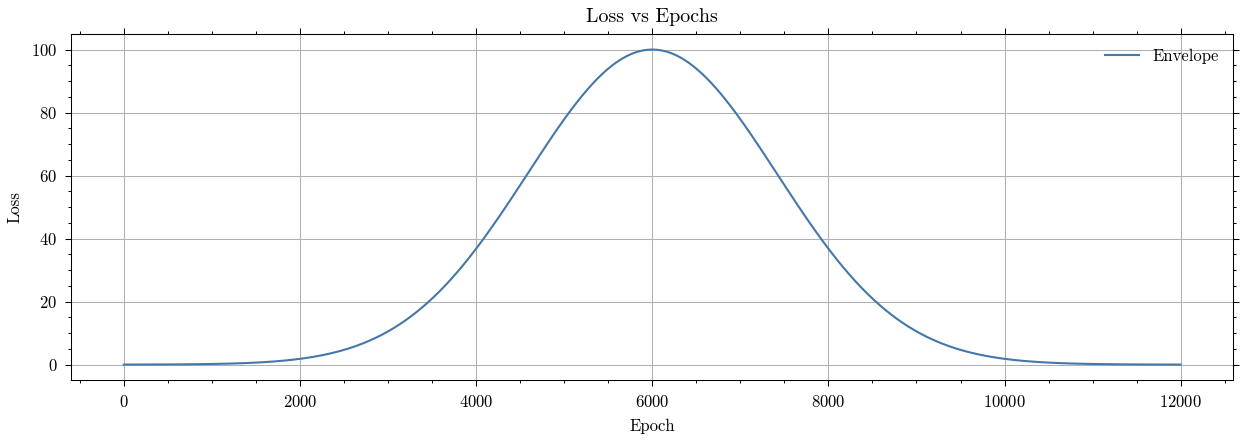

In [45]:
import zodiax as zdx


def envelope(iter, A=1e2, b=5e-4, c=3):
    """
    Returns an envelope function for the given iteration.
    The envelope is defined as A * exp(-b * iter) + c.
    """
    return A * np.exp(-((b * iter - c) ** 2))


@zdx.filter_jit
def get_temperature(args):
    return args["loss"] * envelope(args["t"])


def grads_fn(model, grads, args):
    # Get the parameters
    grad_params = grads.params

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    for filt in grad_params["log_dist"].keys():
        values = grad_params["log_dist"][filt]
        rand_vals = get_temperature(args) * jr.normal(key, values.shape)
        values *= 1 + rand_vals

        grad_params["log_dist"][filt] = values

    # Increment the t parameter
    args["t"] += 1.0

    grads = grads.set("params", grad_params)
    return grads, args


x = np.arange(12000)
envs = envelope(x)


plt.figure(figsize=(10, 3))
plt.plot(x, envs, label="Envelope")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.grid(True)
plt.legend()
plt.show()

In [47]:
n_epoch = len(x)
config = {
    # "log_dist": adam(1e-1, 0, (5000, 0.3)),
    "log_dist": adam(5e-3, 0),
}
args = {
    "loss": np.array(1.0),
    "t": np.array(0.0),
    "reg_dict": {
        "ME": (1e5, dorito.stats.ME),
    },
}

trainer = Train(
    # loss_fn=centered_loss_fn,
    loss_fn=loss_fn,
    grad_fn=grads_fn,
    # loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    # batches=batch_exposures(ois, 4),
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/12000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 318,511.68
Estimated run time: 0:00:59
Full Time: 0:03:27
Final Loss: 244.43


In [48]:
from dorito.plotting import get_arcsec_extents


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = None,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    norm=mpl.colors.PowerNorm(1, vmin=0, vmax=None),
    diff_lim: float = None,
    scale=1.0,
    translate=(0.0, 0.0),
):

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=[0.5, 0, -0.5],
        yticks=[-0.5, 0, 0.5],
        **axis_labels,
    )  # Set the axis labels

    kwargs = {
        "cmap": cmap,
        "extent": get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": norm,
        "aspect": "equal",
    }

    im = ax.imshow(
        array,
        **kwargs,
    )

    if diff_lim is not None:

        centre = 0.95 * np.array(kwargs["extent"][0:2]) + np.array(
            [-diff_lim, diff_lim]
        )

        beam = mpl.patches.Circle(
            centre,
            radius=diff_lim,
            facecolor="white",
            edgecolor="black",
            alpha=0.7,
            zorder=10,
        )
        ax.add_patch(beam)

    if roll_angle_degrees is not None or scale is not None:

        if scale is None:
            scale = 1.0
        if roll_angle_degrees is None:
            roll_angle_degrees = 0.0

        rotation_transform = (
            mpl.transforms.Affine2D()
            .translate(*translate)
            .rotate_deg(roll_angle_degrees)
            .scale(scale)
        )  # Create a rotation transformation
        trans_data = rotation_transform + ax.transData  # creating transformation
        im.set_transform(trans_data)  # applying transformation to image

    return im

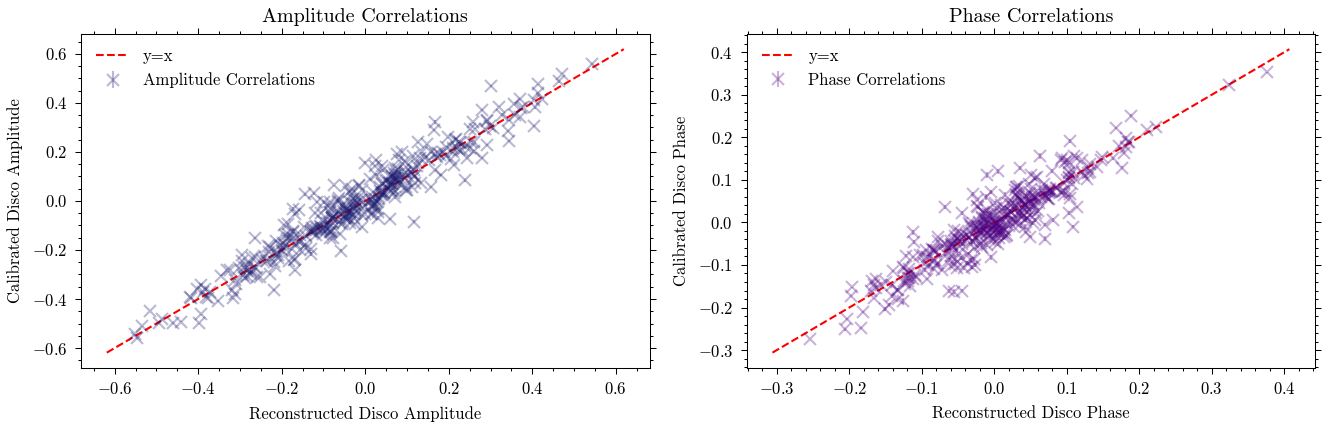

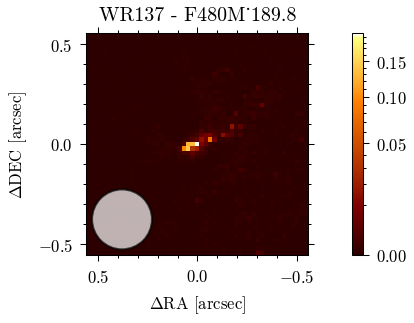

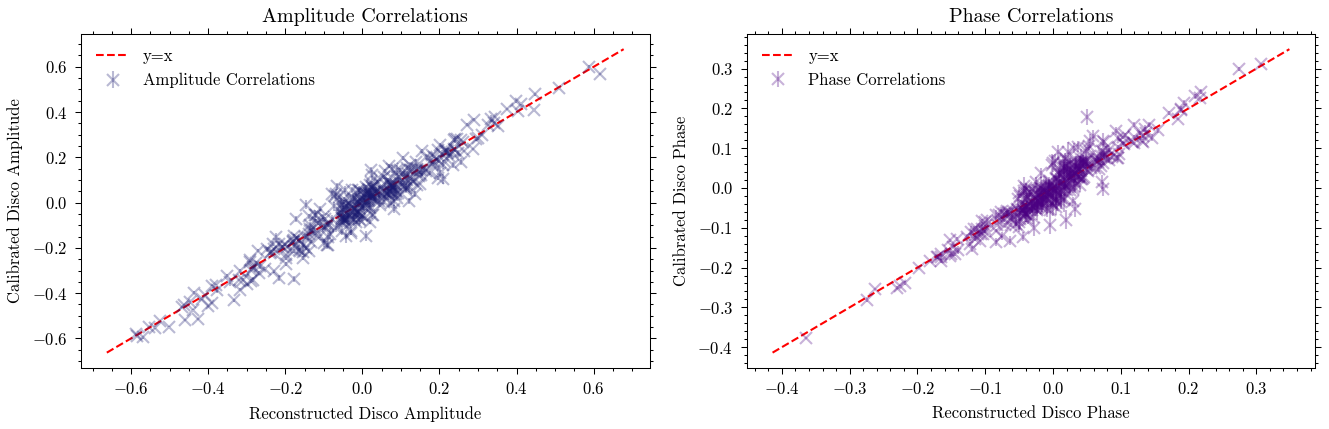

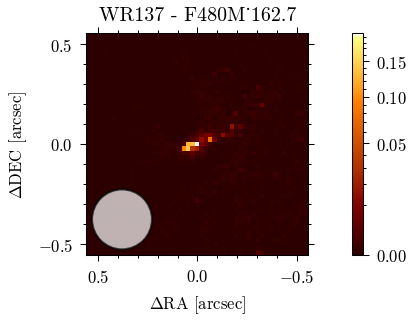

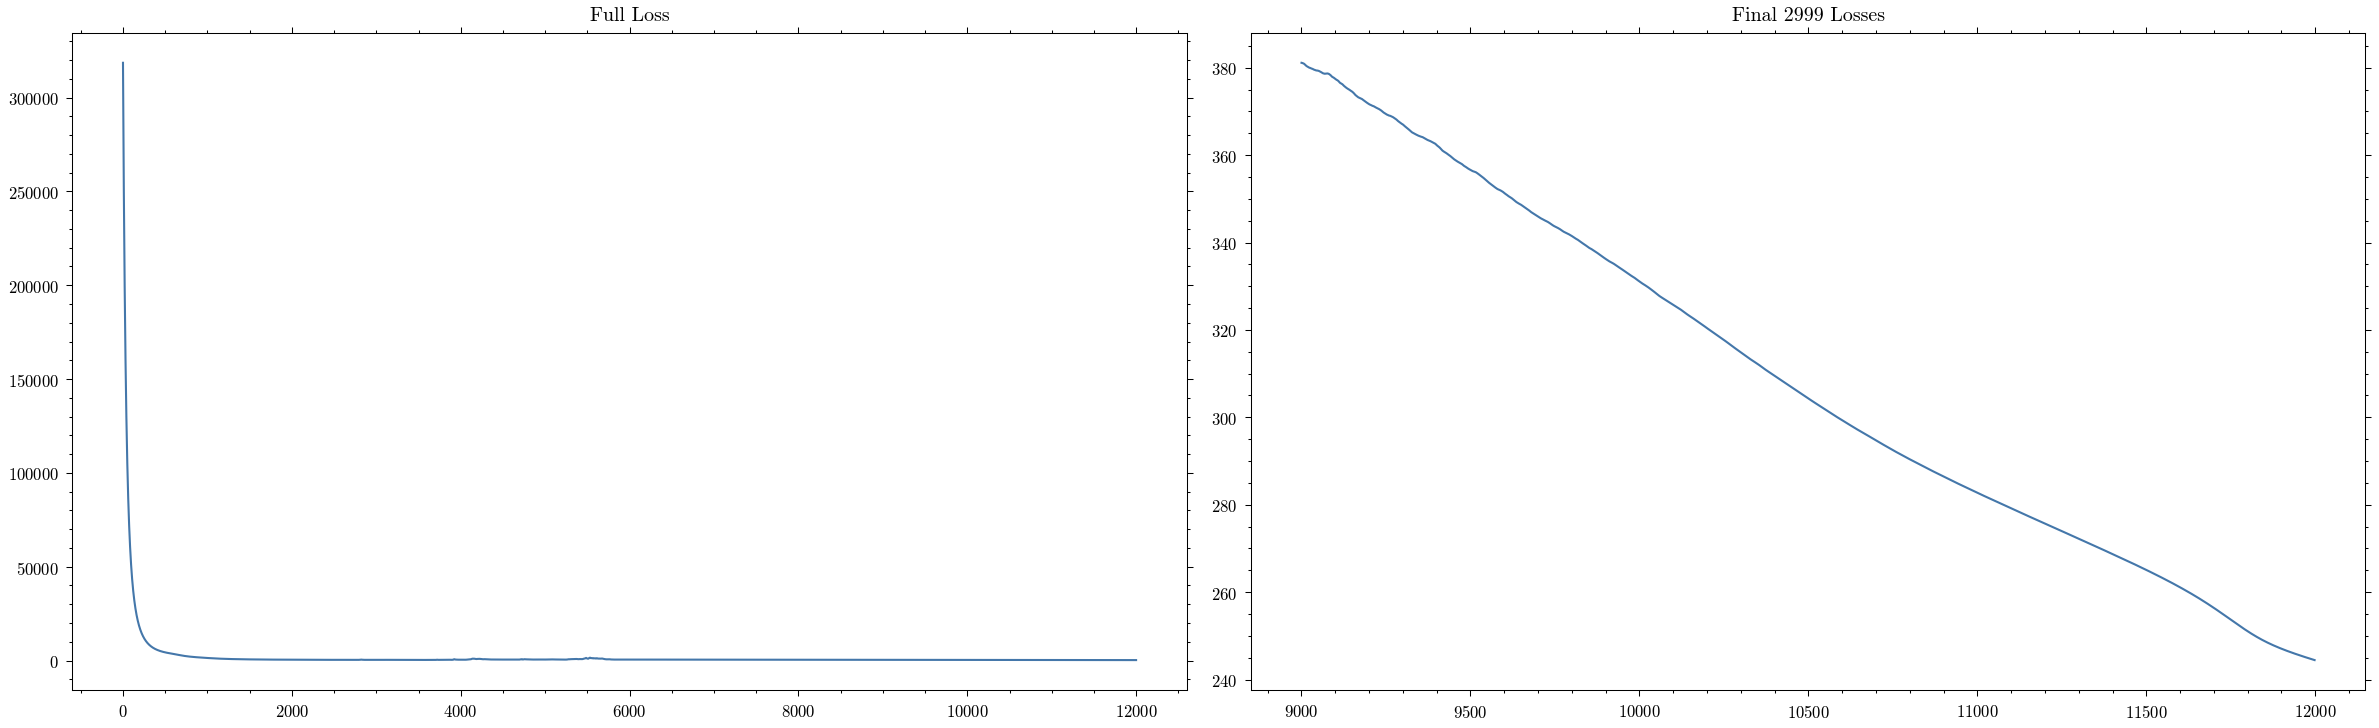

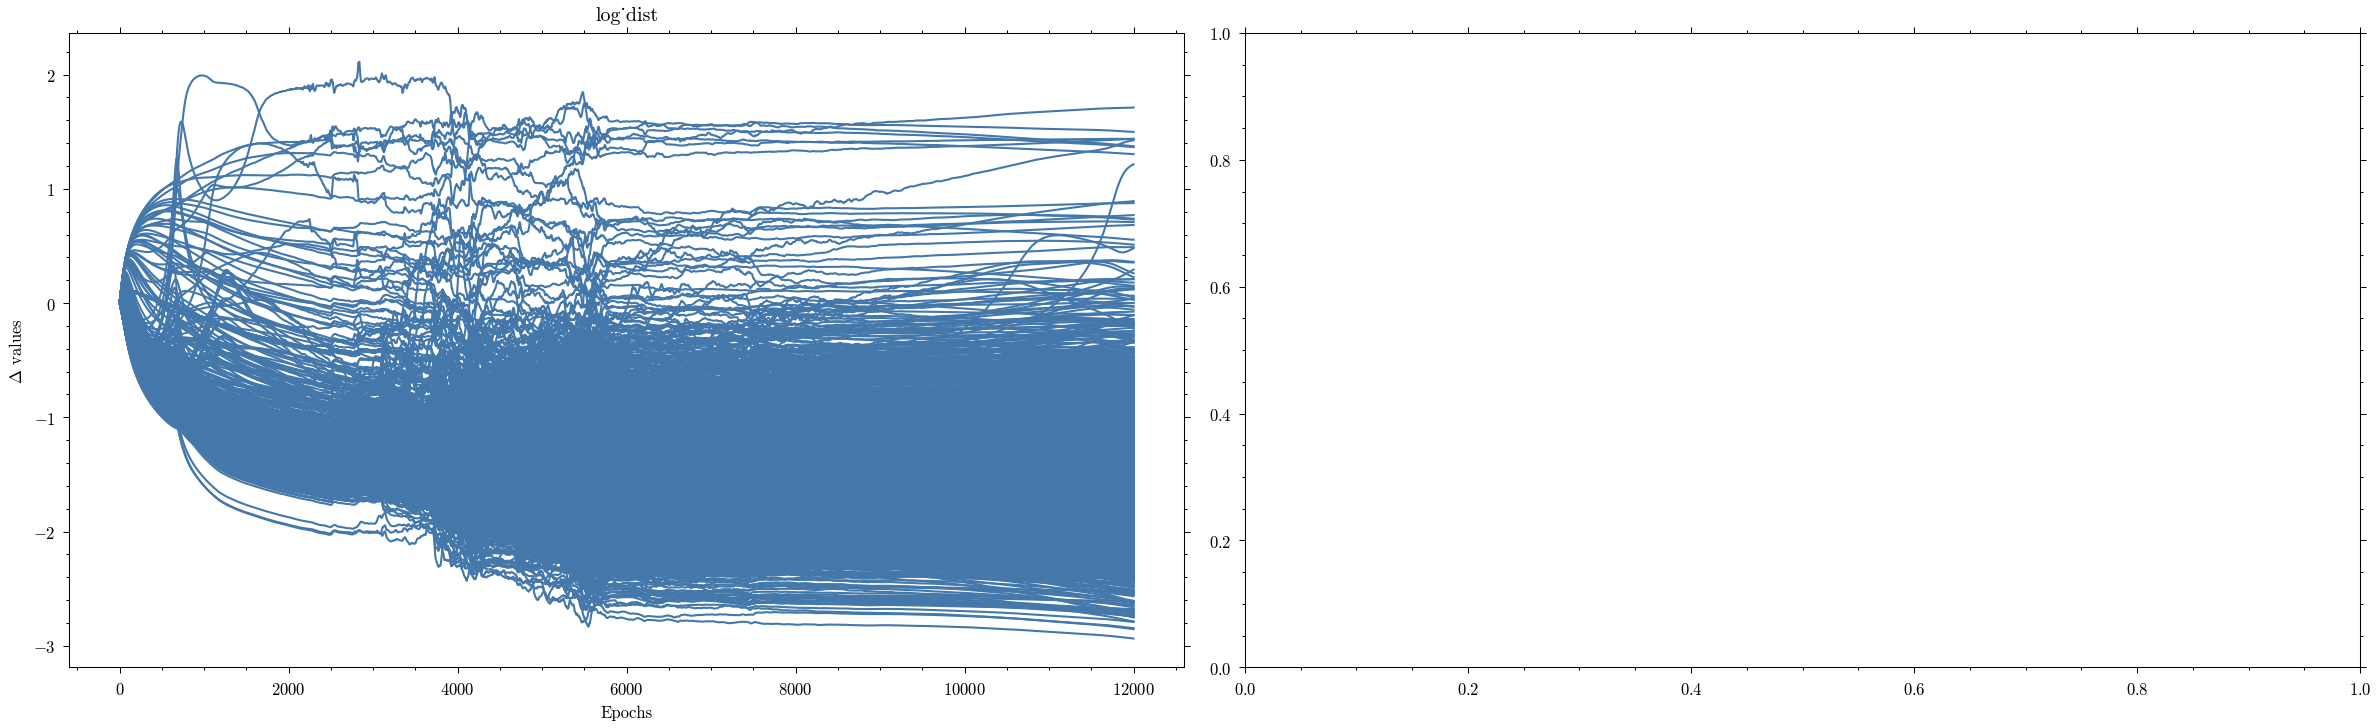

In [49]:
from amigo import plotting

for oi in ois:
    dist = result.model(oi, rotate=False)

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        # power=0.3,
        # vmin=0,
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
        # scale=1.0,
        norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=None),
    )

    fig.colorbar(c0)

    ax.set(title=f"WR137 - {oi.key}")  #   xticks=ticks, yticks=ticks)

    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

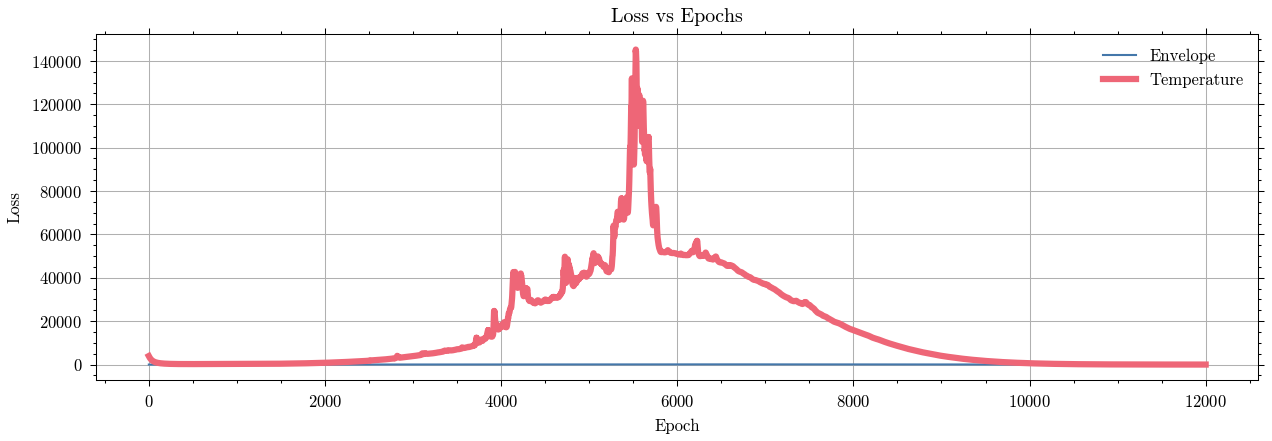

In [50]:
l = np.array(result.losses[0])
# l = l[::5]
x = np.array(range(len(l)))
envs = envelope(x)


plt.figure(figsize=(10, 3))
# plt.plot(x, l, label="Loss")
plt.plot(x, envs, label="Envelope")
plt.plot(
    x,
    l * envs,
    label="Temperature",
    linewidth=3,
)
# plt.yscale("log")
# plt.ylim(0, 1.5e3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.grid(True)
plt.legend()
plt.show()

# NumPyro

In [12]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

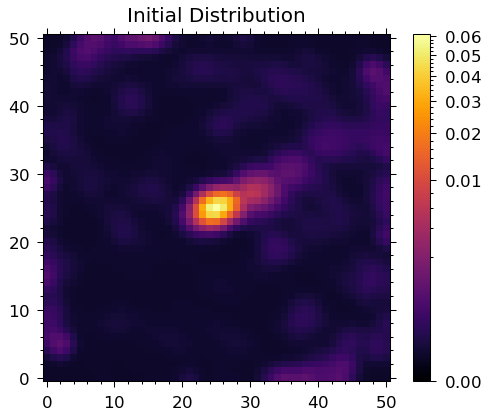

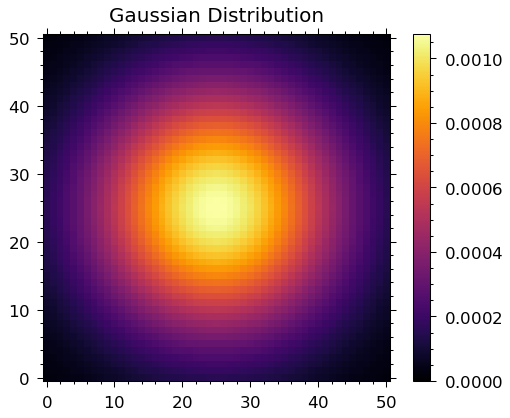

In [ ]:
from scipy.ndimage import gaussian_filter

# np.save("files/paramsF480M.npy", result.model.params, allow_pickle=True)
# np.save("files/paramsF480M_61.npy", result.model.params, allow_pickle=True)
# np.save("files/paramsF480M_51.npy", result.model.params, allow_pickle=True)

params = np.load("files/paramsF480M_51.npy", allow_pickle=True).item()
final_model = model.set("params", params)
# final_model = result.model

MAP = 10 ** final_model.params["log_dist"][oi.get_key("log_dist")]
MAP /= init_dist.sum()
blurred_map = MAP + 1e-5  # to avoid log(0)
blurred_map = gaussian_filter(blurred_map, sigma=1)
blurred_map /= init_dist.sum()
# Replace init_dist with a normalized 2D Gaussian of the same shape
y, x = np.indices(init_dist.shape)
center_y, center_x = np.array(init_dist.shape) // 2
sigma = init_dist.shape[0] / 4  # arbitrary width, adjust as needed

gaussian = np.exp(-((x - center_x) ** 2 + (y - center_y) ** 2) / (2 * sigma**2))
# gaussian = gaussian**0.5
gaussian = gaussian / gaussian.sum()


plt.figure(figsize=(4, 3))
plt.imshow(blurred_map, inferno, norm=mpl.colors.PowerNorm(0.3, vmin=0))
plt.colorbar()
plt.title("Initial Distribution")
plt.show()

plt.figure(figsize=(4, 3))
plt.imshow(gaussian, inferno, norm=mpl.colors.PowerNorm(1.0, vmin=0))
plt.colorbar()
plt.title("Gaussian Distribution")
plt.show()

init_dist = gaussian.copy()
# MAP = final_model.get_distribution(oi)
# MAP /= MAP.sum()  # Normalize the MAP distribution
# init_dist = MAP.copy()

In [ ]:
import numpyro
import chainconsumer
import pandas as pd


def center_of_mass(arr):
    h, w = arr.shape
    y = np.arange(h)
    x = np.arange(w)
    yy, xx = np.meshgrid(y, x, indexing="ij")  # Shape (h, w)

    total_mass = np.sum(arr)
    com_y = np.sum(yy * arr) / total_mass
    com_x = np.sum(xx * arr) / total_mass

    return np.array([com_y, com_x])


O = center_of_mass(init_dist)
print("Initial Centroid (y, x):", O)

Initial Centroid (y, x): [25. 25.]


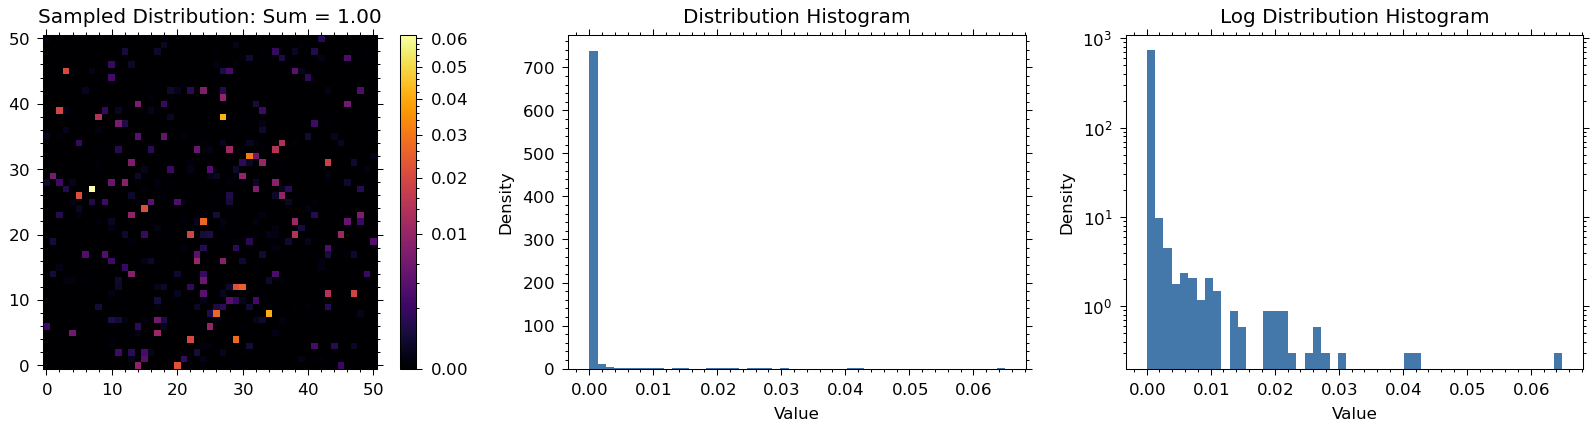

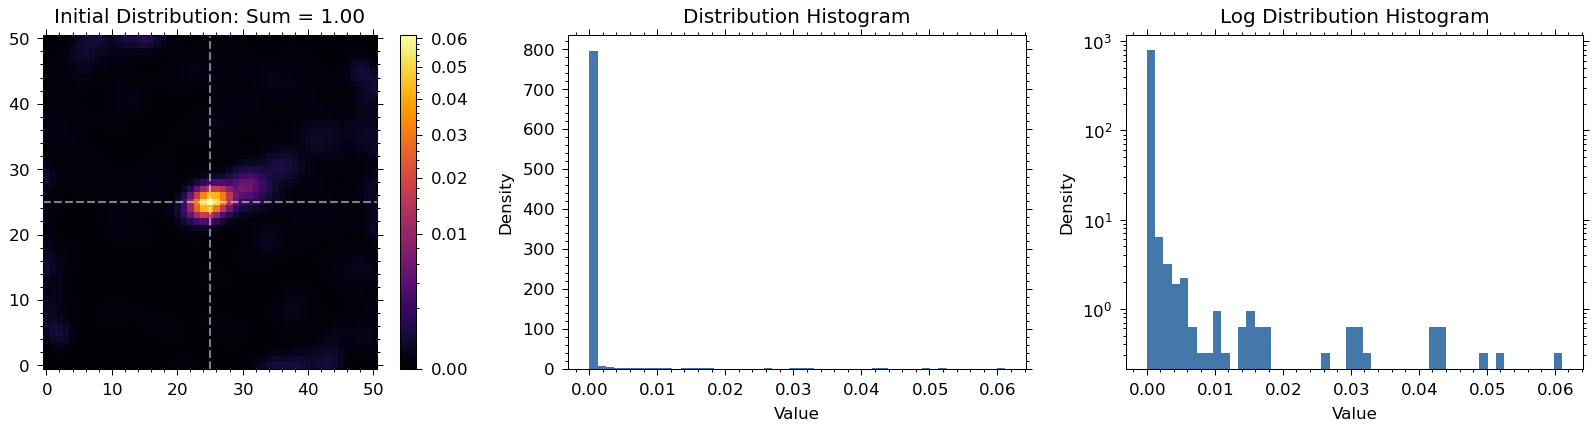

In [ ]:
size = 51

# Dirichlet distribution
sampled_dist = numpyro.sample(
    name="dist",
    fn=numpyro.distributions.Dirichlet((gaussian**0.5).flatten()),  # prior strength
    # fn=numpyro.distributions.Dirichlet(np.ones(size**2) * 1.5),  # prior strength
    rng_key=jax.random.PRNGKey(0),
)
sampled_dist = sampled_dist.reshape((size, size))

fig, ax = plt.subplots(1, 3, figsize=(11, 3))

im = ax[0].imshow(
    sampled_dist, norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=blurred_map.max())
)
ax[0].set_title(f"Sampled Distribution: Sum = {sampled_dist.sum():.2f}")
fig.colorbar(im, ax=ax[0])

ax[1].hist(sampled_dist.flatten(), bins=50, density=True, alpha=1)
ax[1].set_title("Distribution Histogram")
ax[1].set_xlabel("Value")
ax[1].set_ylabel("Density")

ax[2].hist(sampled_dist.flatten(), bins=50, density=True, alpha=1)
ax[2].set_yscale("log")
ax[2].set_title("Log Distribution Histogram")
ax[2].set_xlabel("Value")
ax[2].set_ylabel("Density")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(11, 3))

im = ax[0].imshow(
    blurred_map, norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=blurred_map.max())
)
ax[0].set_title(f"Initial Distribution: Sum = {init_dist.sum():.2f}")
ax[0].axvline(O[1], color="white", linestyle="--", label="Centroid X", alpha=0.5)
ax[0].axhline(O[0], color="white", linestyle="--", label="Centroid Y", alpha=0.5)
# ax[0].legend()
fig.colorbar(im, ax=ax[0])

ax[1].hist(blurred_map.flatten(), bins=50, density=True, alpha=1)
ax[1].set_title("Distribution Histogram")
ax[1].set_xlabel("Value")
ax[1].set_ylabel("Density")

ax[2].hist(blurred_map.flatten(), bins=50, density=True, alpha=1)
ax[2].set_yscale("log")
ax[2].set_title("Log Distribution Histogram")
ax[2].set_xlabel("Value")
ax[2].set_ylabel("Density")

plt.tight_layout()
plt.show()

Compiling the model...
Compiling the model...


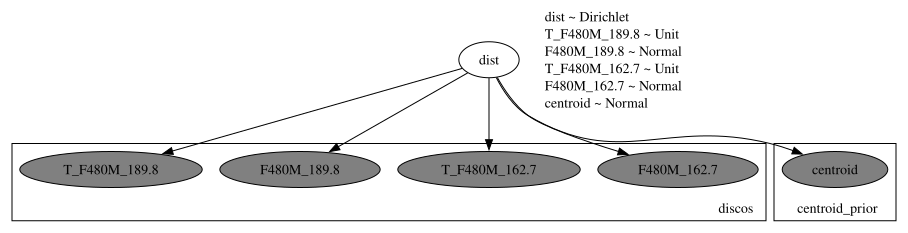

In [ ]:
from jax.scipy.signal import convolve2d
from jax import random as jr

prior_dist = (gaussian**0.5).flatten()

# ...existing code...


def numpyro_model(ois, model, temperature=1.0):
    print("Compiling the model...")

    params = model.params

    # Sample from a Dirichlet: gives shape (size * size,) and sums to 1
    # rng_key, _key = jr.split(rng_key)
    draw = numpyro.sample(
        "dist",
        numpyro.distributions.Dirichlet(prior_dist),  # prior strength
        # rng_key=_key,
    )

    # Sample from a Dirichlet: gives shape (size * size,) and sums to 1
    dist = draw.reshape((size, size))
    log_dist = np.log10(dist)

    with numpyro.plate("discos", len(np.concat([ois[0].vis, ois[0].phi]))):

        for oi in ois:
            discos = np.concat([oi.vis, oi.phi])
            err = np.concat([oi.d_vis, oi.d_phi])

            # Update model log_dist using base-10 log of normalized values
            params["log_dist"][oi.get_key("log_dist")] = log_dist
            model_discos = oi(model.set("params", params))
            # Scale the log-likelihood by 1/temperature
            numpyro.factor(
                f"T_{oi.key}",
                (1.0 / temperature - 1.0)
                * numpyro.distributions.Normal(model_discos, err)
                .log_prob(discos)
                .sum(),
            )
            numpyro.sample(
                f"{oi.key}",
                numpyro.distributions.Normal(model_discos, err),
                obs=discos,
            )

    # Centre of mass prior
    with numpyro.plate("centroid_prior", 2):
        centroid = center_of_mass(dist)
        numpyro.sample(
            "centroid",
            numpyro.distributions.Normal(centroid, 1.0),  # Prior for the centroid
            obs=O,
        )


# ...existing code...


numpyro.render_model(
    numpyro_model, model_args=(ois, final_model), render_distributions=True
)

In [ ]:
# from numpyro.infer import init_to_value

# sampler = numpyro.infer.MCMC(
#     numpyro.infer.NUTS(
#         numpyro_model,
#         init_strategy=init_to_value(values={"dist": init_dist.flatten()}),
#     ),
#     num_chains=1,
#     num_samples=500,
#     num_warmup=50,
# )
# sampler.run(jax.random.PRNGKey(0), ois, final_model)

In [ ]:
# ...existing code...

from numpyro.infer import init_to_value

# temperatures = [10.0, 5.0, 2.0, 1.5, 1.2, 1.0]  # Example schedule, high to low
temperatures = [1.0]  # Example schedule, high to low
samples_per_temp = {}

for temp in temperatures:
    print(f"Running MCMC at temperature {temp}")
    sampler = numpyro.infer.MCMC(
        numpyro.infer.NUTS(
            lambda *args, **kwargs: numpyro_model(*args, **kwargs, temperature=temp),
            init_strategy=init_to_value(values={"dist": init_dist.flatten()}),
            max_tree_depth=13,  # Increase max_tree_depth for better exploration
            target_accept_prob=0.44,
            # step_size=1000,
        ),
        num_chains=1,
        num_samples=100,
        num_warmup=300,
    )
    sampler.run(jax.random.PRNGKey(0), ois[0:1], final_model)
    samples = sampler.get_samples()
    samples_per_temp[temp] = samples
    # Optionally, update init_dist_current for the next temperature using the mean of the last samples
    init_dist_current = samples["dist"].mean(axis=0).reshape((size, size))

Running MCMC at temperature 1.0
Compiling the model...
Compiling the model...


  0%|          | 0/400 [00:00<?, ?it/s]

Compiling the model...


warmup:  48%|████▊     | 190/400 [06:17<22:27,  6.41s/it, 8191 steps of size 3.54e-12. acc. prob=0.35]

Parameter PIX01295 in chain MCMC is not constrained
Parameter PIX01296 in chain MCMC is not constrained
Parameter PIX01297 in chain MCMC is not constrained
Parameter PIX01298 in chain MCMC is not constrained
Parameter PIX01299 in chain MCMC is not constrained
Parameter PIX01300 in chain MCMC is not constrained
Parameter PIX01301 in chain MCMC is not constrained
Parameter PIX01302 in chain MCMC is not constrained
Parameter PIX01303 in chain MCMC is not constrained
Parameter PIX01304 in chain MCMC is not constrained


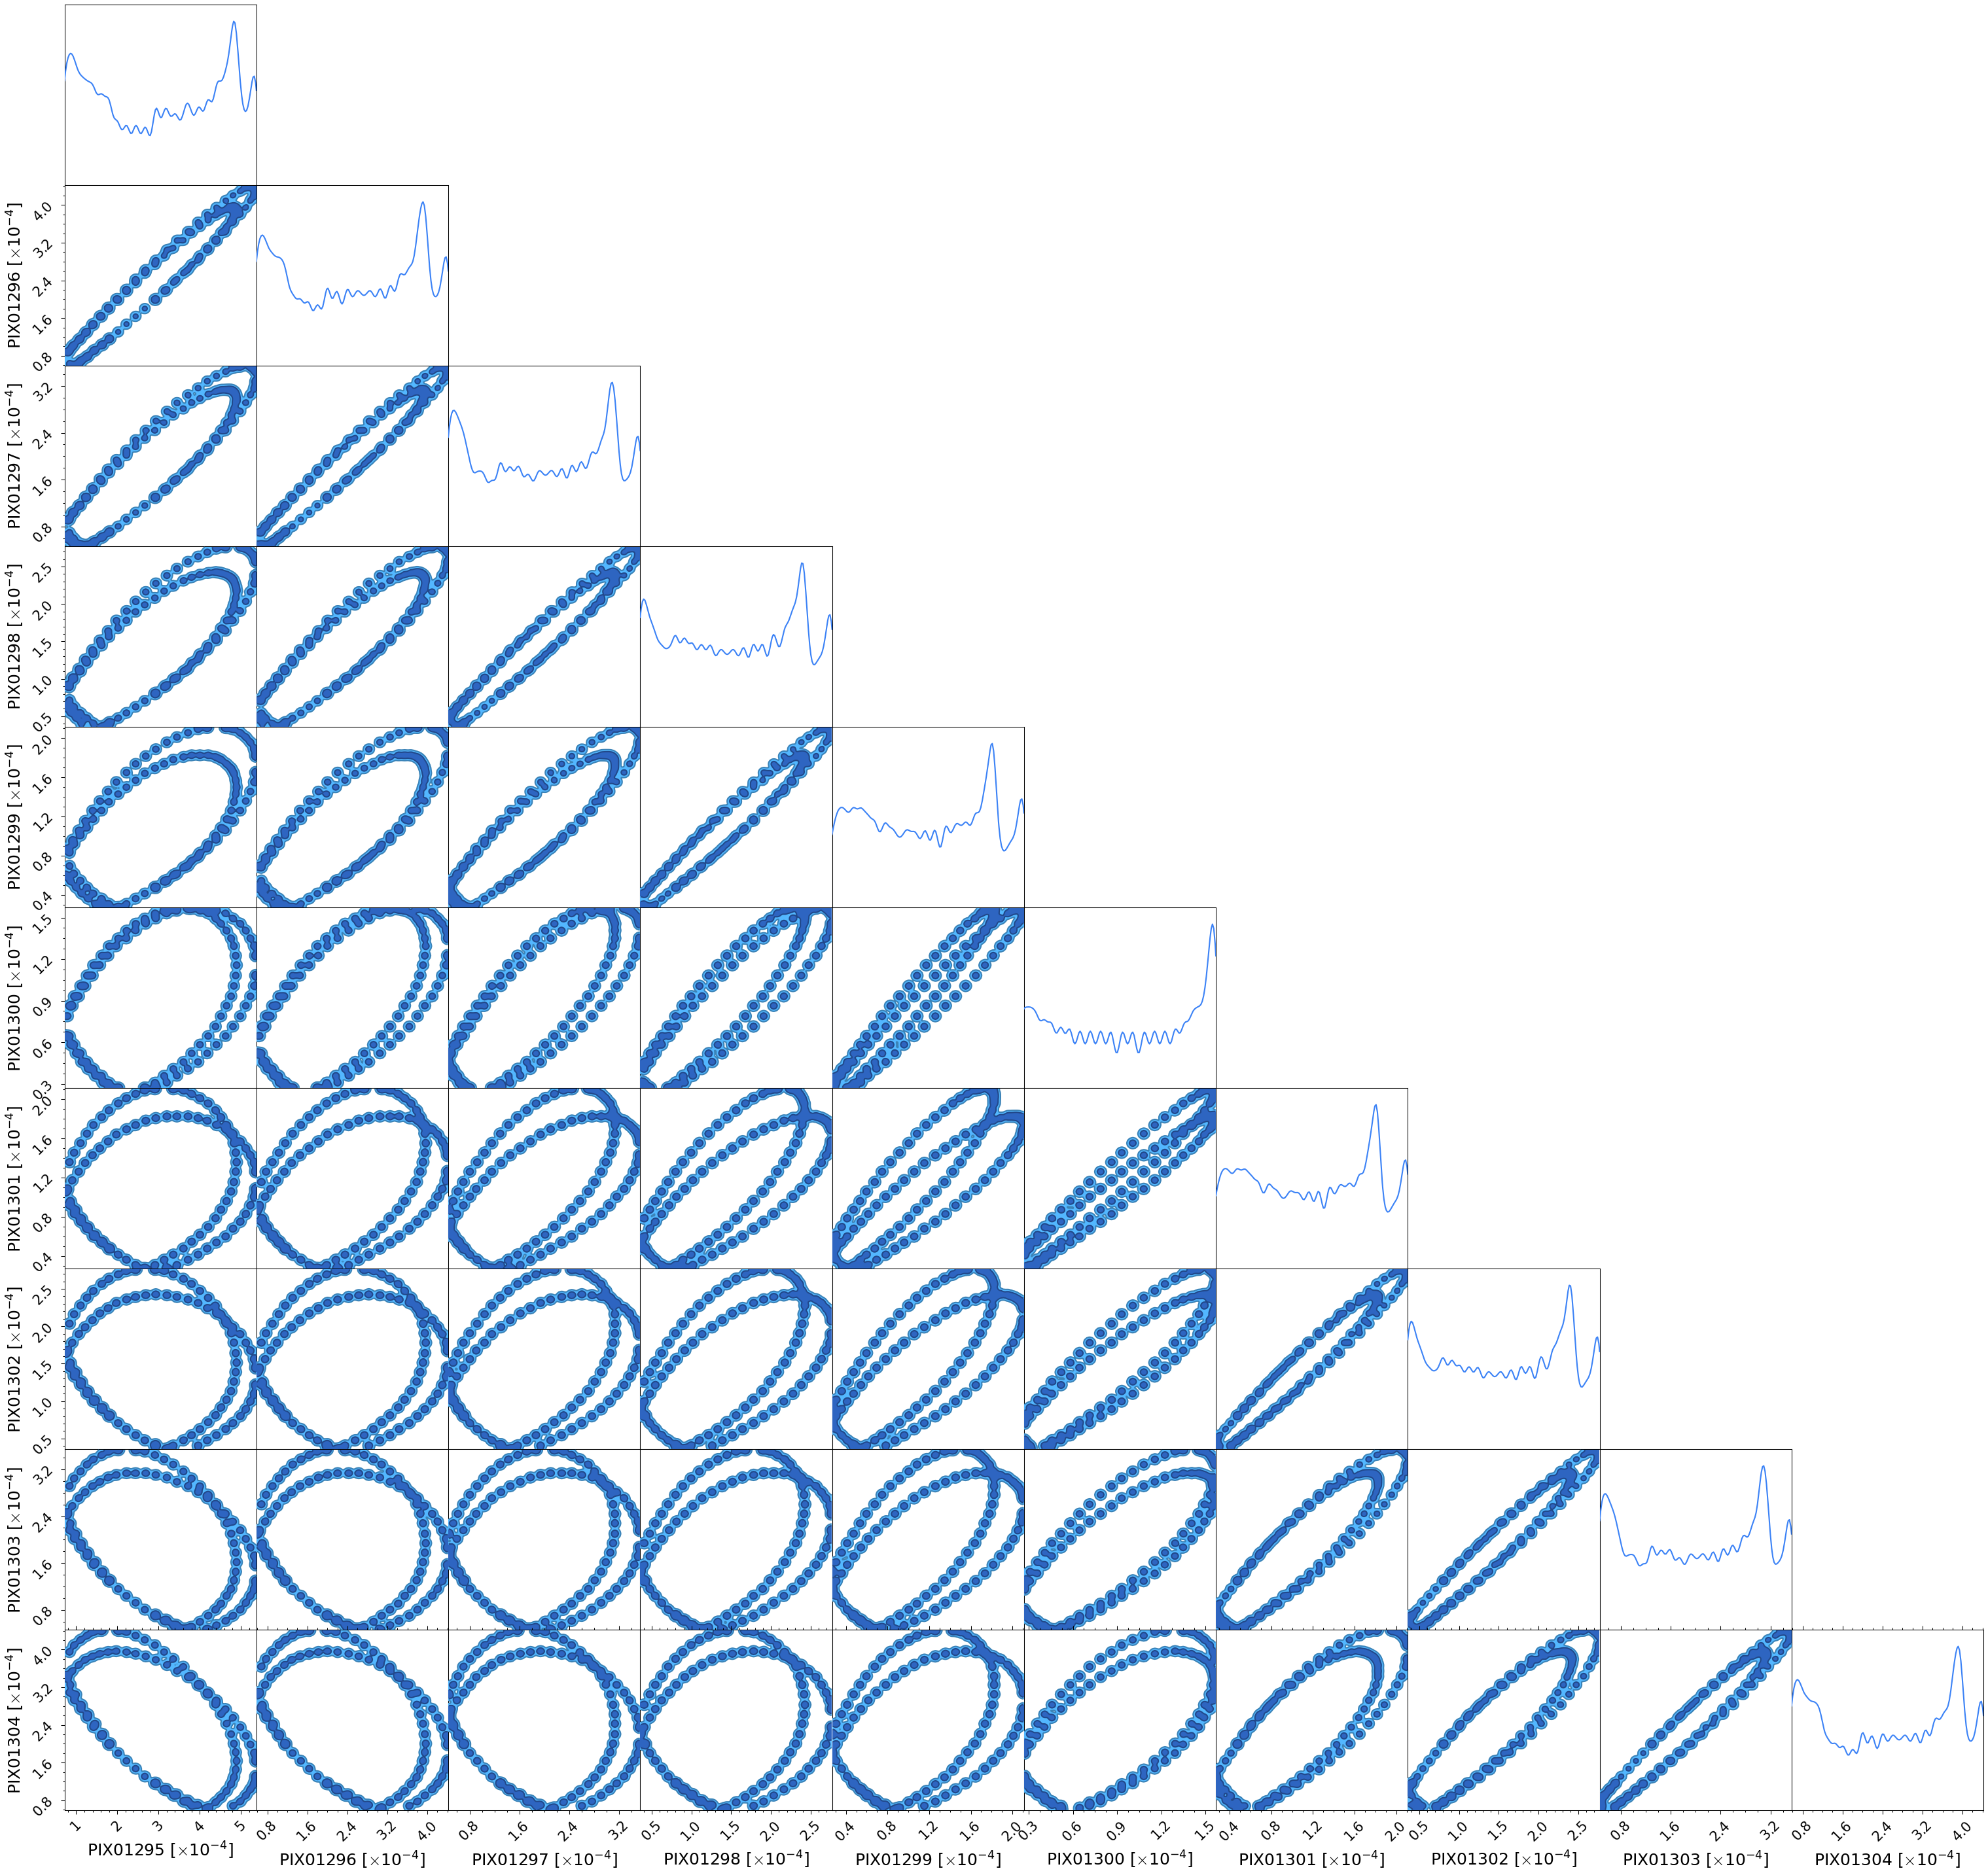

In [ ]:
# samples = sampler.get_samples()
# np.save("files/20_000_samples.npy", samples, allow_pickle=True)

# samples = np.load("files/5000_samples.npy", allow_pickle=True).item()

# Calculate mean and stddev across the chain
mean_image = samples["dist"].mean(axis=0).reshape((size, size))
std_image = samples["dist"].std(axis=0).reshape((size, size))

formatted_samples = {}
for i, pixel in enumerate(samples["dist"].reshape(size * size, -1)):
    formatted_samples[f"PIX{i:05d}"] = pixel
formatted_samples = pd.DataFrame(formatted_samples)
middle = np.argmax(samples["dist"].mean(axis=0))
cols = [f"PIX{i:05d}" for i in range(middle - 5, middle + 5)]


C = chainconsumer.ChainConsumer()
chain = chainconsumer.Chain(samples=pd.DataFrame(formatted_samples[cols]), name="MCMC")
# C.add_truth(chainconsumer.Truth(location={"m": m_true, "c": c_true}))
C.add_chain(chain)
fig = C.plotter.plot()
plt.show()

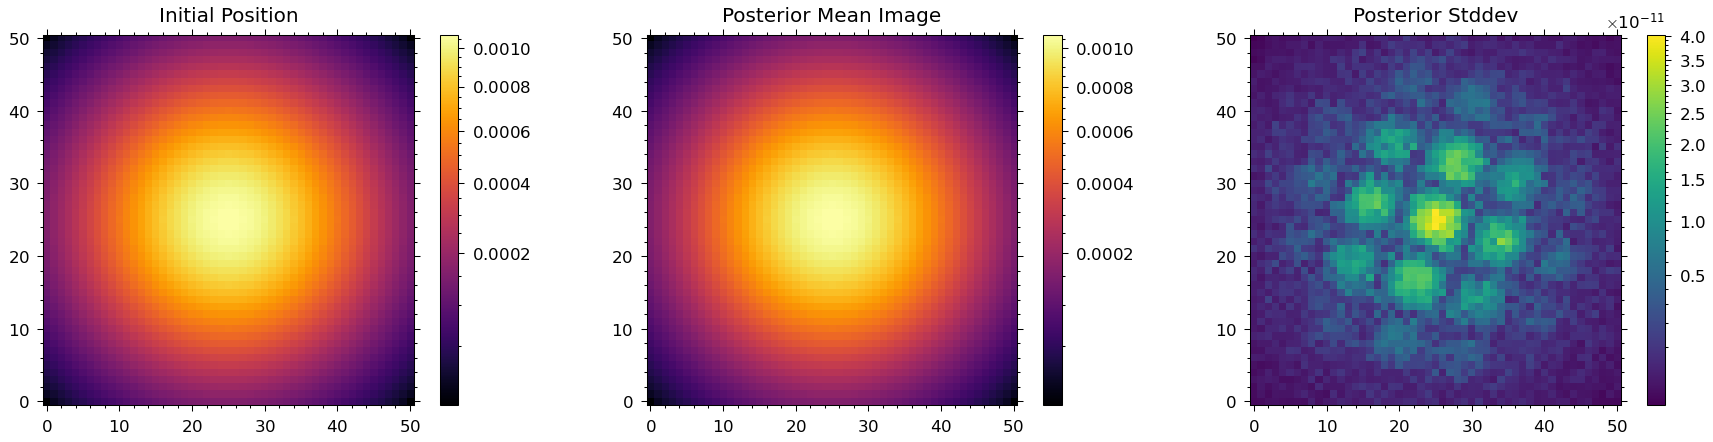

In [ ]:
# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Posterior Mean
im0 = axes[0].imshow(
    init_dist,
    inferno,
    norm=mpl.colors.PowerNorm(0.5),
)
axes[0].set_title("Initial Position")
fig.colorbar(im0, ax=axes[0])

# Posterior Stddev
im1 = axes[1].imshow(
    mean_image,
    inferno,
    norm=mpl.colors.PowerNorm(0.5),
)
axes[1].set_title("Posterior Mean Image")
fig.colorbar(im1, ax=axes[1])

# SNR
im1 = axes[2].imshow(
    std_image,
    origin="lower",
    cmap="viridis",
    norm=mpl.colors.PowerNorm(0.5),
)
axes[2].set_title("Posterior Stddev")
fig.colorbar(im1, ax=axes[2])

plt.tight_layout()
plt.show()

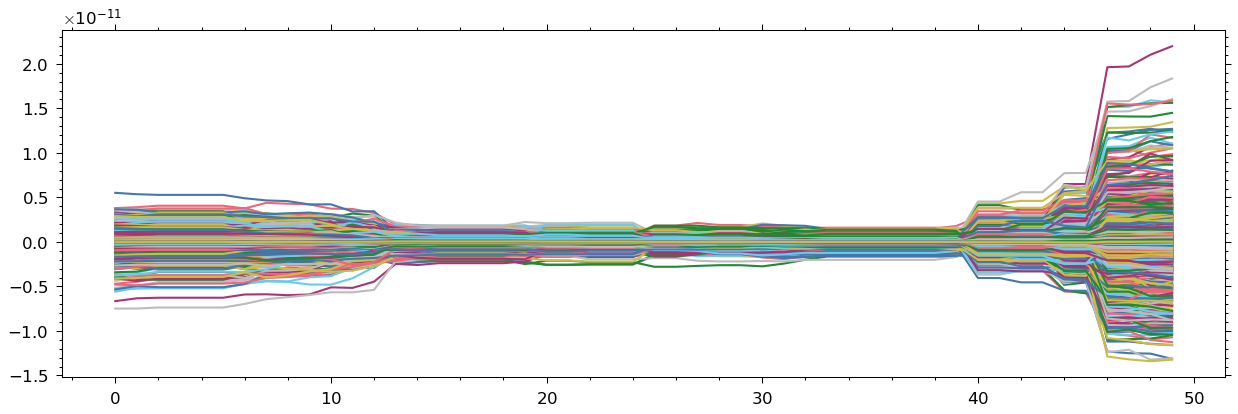

In [ ]:
x = samples_per_temp[1.0]["dist"]

plt.figure(figsize=(10, 3))
plt.plot(x - x.mean(axis=0))
plt.show()

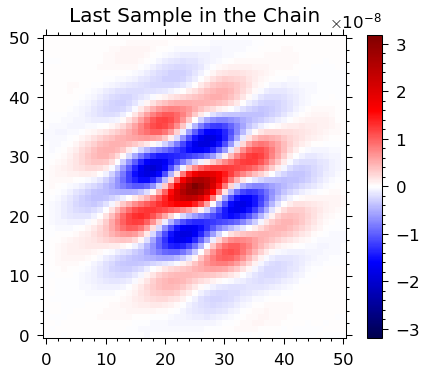

In [ ]:
# plt.imshow(mean_image - init_dist, cmap=seismic)
# plt.colorbar()
# plt.show()

last = samples["dist"][-1].reshape((size, size))  # Last sample in the chain
plt.imshow(last - init_dist, cmap=seismic, norm=mpl.colors.CenteredNorm())
plt.colorbar()
plt.title("Last Sample in the Chain")
plt.show()

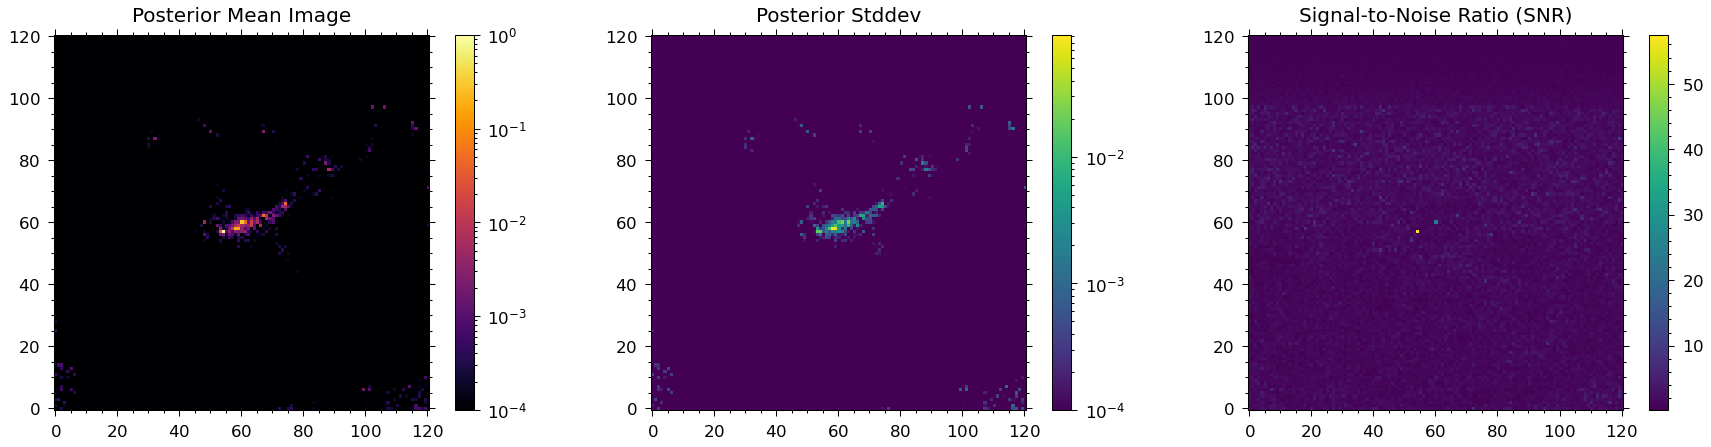

In [ ]:
# Plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Posterior Mean
im0 = axes[0].imshow(
    mean_image / mean_image.max(),
    inferno,
    norm=mpl.colors.LogNorm(vmin=1e-4),
)
axes[0].set_title("Posterior Mean Image")
fig.colorbar(im0, ax=axes[0])

# Posterior Stddev
im1 = axes[1].imshow(
    std_image / mean_image.max(),
    origin="lower",
    cmap="viridis",
    norm=mpl.colors.LogNorm(vmin=1e-4),
)
axes[1].set_title("Posterior Stddev")
fig.colorbar(im1, ax=axes[1])

# SNR
im1 = axes[2].imshow(
    mean_image / std_image,
    origin="lower",
    cmap="viridis",
    # norm=mpl.colors.LogNorm(vmin=1e-4),
)
axes[2].set_title("Signal-to-Noise Ratio (SNR)")
fig.colorbar(im1, ax=axes[2])

plt.tight_layout()
plt.show()

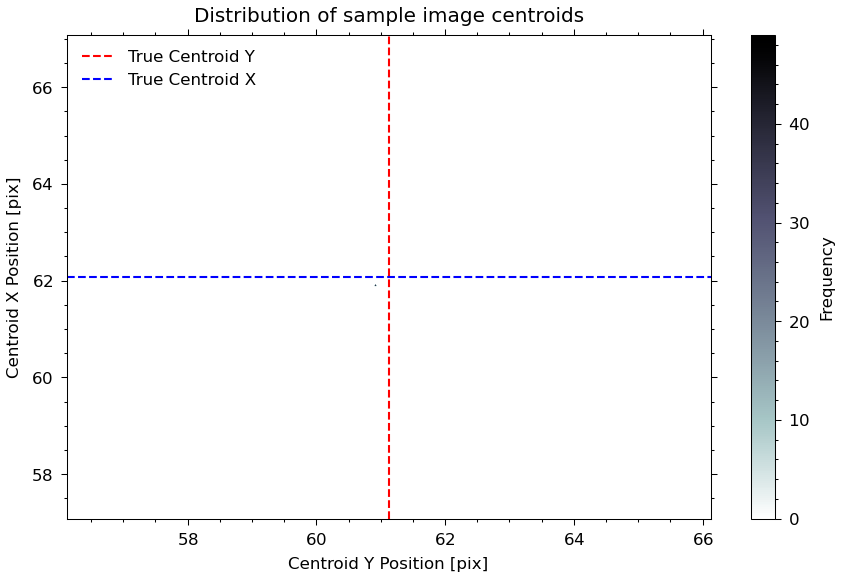

In [ ]:
# centroids = np.array(
#     [center_of_mass(dist.reshape((size, size))) for dist in samples["dist"]]
# )

centroids = jax.vmap(center_of_mass)(samples["dist"].reshape((-1, size, size)))

width = 10.0  # pix

plt.figure(figsize=(6, 4))
plt.hist2d(centroids[:, 0], centroids[:, 1], bins=30, cmap="bone_ur")
plt.colorbar(label="Frequency")
plt.xlabel("Centroid Y Position [pix]")
plt.ylabel("Centroid X Position [pix]")
plt.title("Distribution of sample image centroids")
plt.axvline(O[0], color="red", linestyle="--", label="True Centroid Y")
plt.axhline(O[1], color="blue", linestyle="--", label="True Centroid X")
plt.legend(loc="upper left")
plt.xlim(O[0] - width / 2, O[0] + width / 2)
plt.ylim(O[1] - width / 2, O[1] + width / 2)
plt.tight_layout()
plt.show()

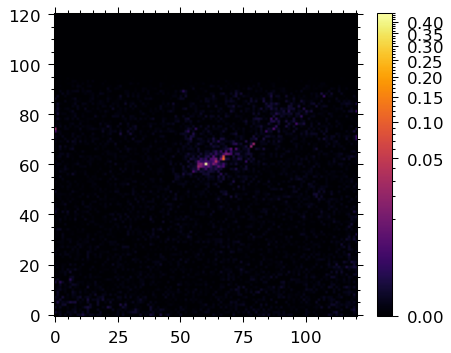

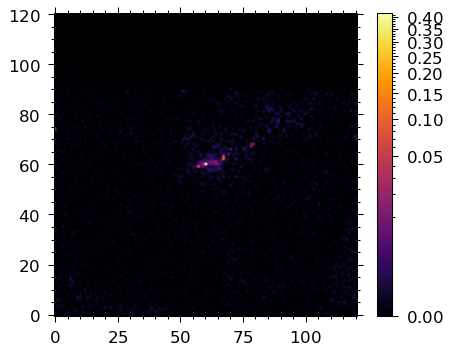

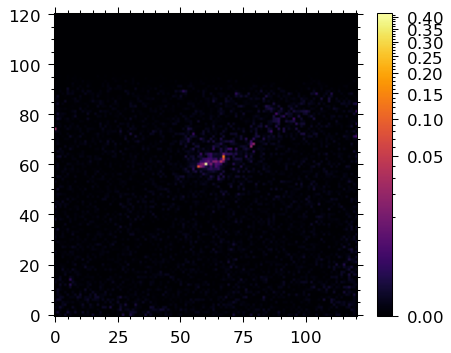

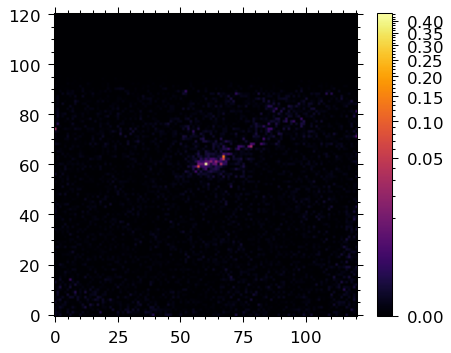

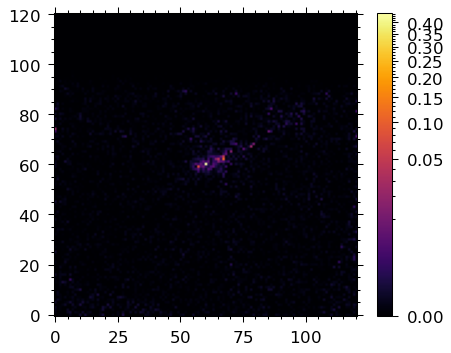

In [ ]:
for dist in samples["dist"][:5]:
    dist = dist.reshape((size, size))

    plt.imshow(dist, inferno, norm=mpl.colors.PowerNorm(0.3, vmin=0))
    plt.colorbar()
    plt.show()

# BlackJAX

In [ ]:
# from numpyro.infer.util import initialize_model, init_to_value
# from jax import random as jr

# rng_key, rng_subkey = jr.split(jr.PRNGKey(0))
# param_info, potential_fn, postprocess_fn, *_ = initialize_model(
#     rng_subkey,
#     numpyro_model,
#     model_args=(ois[0:1], final_model),
#     init_strategy=init_to_value(values={"dist": init_dist.flatten()}),
#     dynamic_args=True,
# )

# constrain_fn = postprocess_fn(ois[0], final_model)

Compiling the model...
Compiling the model...


In [ ]:
# # get log-density from the potential function
# def logdensity_fn(position):
#     func = potential_fn(ois[0:1], final_model)
#     return -func(position)


# logdensity_fn(param_info.z)

Compiling the model...


Array(-2507877.54188416, dtype=float64)

In [ ]:
# from tqdm.notebook import tqdm
# import blackjax


# def inference_loop(rng_key, kernel, initial_state, num_samples):
#     @jax.jit
#     def one_step(state, rng_key):
#         state, info = kernel.step(rng_key, state)
#         return state, (state, info)

#     keys = jax.random.split(rng_key, num_samples)
#     _, (states, infos) = jax.lax.scan(one_step, initial_state, keys)

#     return states, (
#         infos.acceptance_rate,
#         infos.is_divergent,
#         infos.num_integration_steps,
#     )


# def chunked_inference_loop(rng_key, kernel, initial_state, num_samples, chunk_size=100):
#     num_chunks = num_samples // chunk_size
#     remainder = num_samples % chunk_size

#     all_states = []
#     all_acceptance = []
#     all_divergent = []
#     all_steps = []

#     state = initial_state

#     for _ in tqdm(range(num_chunks + (1 if remainder else 0))):
#         this_chunk = chunk_size if _ < num_chunks else remainder
#         if this_chunk == 0:
#             continue

#         rng_key, subkey = jax.random.split(rng_key)
#         keys = jax.random.split(subkey, this_chunk)

#         def scan_step(state, key):
#             state, info = kernel.step(key, state)
#             return state, (state, info)

#         state, (states, infos) = jax.lax.scan(scan_step, state, keys)

#         all_states.append(states)
#         all_acceptance.append(infos.acceptance_rate)
#         all_divergent.append(infos.is_divergent)
#         all_steps.append(infos.num_integration_steps)

#     # Concatenate everything
#     states = jax.tree.map(lambda *xs: np.concatenate(xs), *all_states)
#     acceptance = np.concatenate(all_acceptance)
#     divergent = np.concatenate(all_divergent)
#     steps = np.concatenate(all_steps)

#     return states, (acceptance, divergent, steps)

## NUTS

In [ ]:
# num_warmup = 200

# adapt = blackjax.window_adaptation(
#     blackjax.nuts, logdensity_fn, target_acceptance_rate=0.8
# )
# rng_key, warmup_key = jr.split(rng_key)
# (last_state, parameters), _ = adapt.run(warmup_key, param_info.z, num_warmup)
# kernel = blackjax.nuts(logdensity_fn, **parameters)

Compiling the model...
Compiling the model...
Compiling the model...
Compiling the model...


In [ ]:
# num_sample = 20
# rng_key, sample_key = jax.random.split(rng_key)

# states, infos = chunked_inference_loop(
#     sample_key, kernel, last_state, num_sample, chunk_size=25
# )

# acceptance_rate = np.mean(infos[0])
# num_divergent = np.mean(infos[1])
# print(f"Average acceptance rate: {acceptance_rate:.2f}")
# print(f"There were {100*num_divergent:.2f}% divergent transitions")

  0%|          | 0/1 [00:00<?, ?it/s]

Compiling the model...
Compiling the model...
Compiling the model...
Average acceptance rate: 0.83
There were 10.00% divergent transitions


## Tempered

```python
def as_top_level_api(
    logprior_fn: Callable,
    loglikelihood_fn: Callable,
    mcmc_step_fn: Callable,
    mcmc_init_fn: Callable,
    mcmc_parameters: dict,
    resampling_fn: Callable,
    num_mcmc_steps: Optional[int] = 10,
    update_strategy=update_and_take_last,
) -> SamplingAlgorithm:
    """Implements the (basic) user interface for the Adaptive Tempered SMC kernel.

    Parameters
    ----------
    logprior_fn
        The log-prior function of the model we wish to draw samples from.
    loglikelihood_fn
        The log-likelihood function of the model we wish to draw samples from.
    mcmc_step_fn
        The MCMC step function used to update the particles.
    mcmc_init_fn
        The MCMC init function used to build a MCMC state from a particle position.
    mcmc_parameters
        The parameters of the MCMC step function.  Parameters with leading dimension
        length of 1 are shared amongst the particles.
    resampling_fn
        The function used to resample the particles.
    num_mcmc_steps
        The number of times the MCMC kernel is applied to the particles per step.

    Returns
    -------
    A ``SamplingAlgorithm``.

```

In [ ]:
# from blackjax.smc import extend_params, resampling


# def tuned_adaptive_tempered_inference_loop(kernel, rng_key, initial_state):
#     def cond(carry):
#         _, state, *_ = carry
#         return state.lmbda < 1

#     def body(carry):
#         i, state, curr_loglikelihood = carry
#         subkey = jax.random.fold_in(rng_key, i)
#         state, info = kernel(subkey, state)
#         return i + 1, state, curr_loglikelihood + info.log_likelihood_increment

#     total_iter, final_state, log_likelihood = jax.lax.while_loop(
#         cond, body, (0, initial_state, 0.0)
#     )
#     return total_iter, final_state, log_likelihood


# n_samples = 2

# tempered_kernel = blackjax.adaptive_tempered_smc(
#     logprior_fn=lambda x: 0.0,  # No prior
#     loglikelihood_fn=logdensity_fn,
#     mcmc_step_fn=blackjax.nuts.build_kernel(),
#     mcmc_init_fn=blackjax.nuts.init,
#     mcmc_parameters=extend_params(parameters),
#     resampling_fn=resampling.systematic,
#     target_ess=0.5,
#     num_mcmc_steps=1,
# )

# rng_key, init_key, sample_key = jax.random.split(rng_key, 3)
# initial_smc_state = jr.multivariate_normal(
#     init_key, np.zeros([1]), np.eye(1), (n_samples, 14640)
# )
# initial_smc_state = tempered_kernel.init(initial_smc_state)

# total_iter, final_state, log_likelihood = tuned_adaptive_tempered_inference_loop(
#     tempered_kernel.step, init_key, initial_smc_state
# )
# # print("Number of steps in the adaptive algorithm: ", n_iter.item())

Compiling the model...
Compiling the model...
Compiling the model...
Compiling the model...
Compiling the model...
Compiling the model...


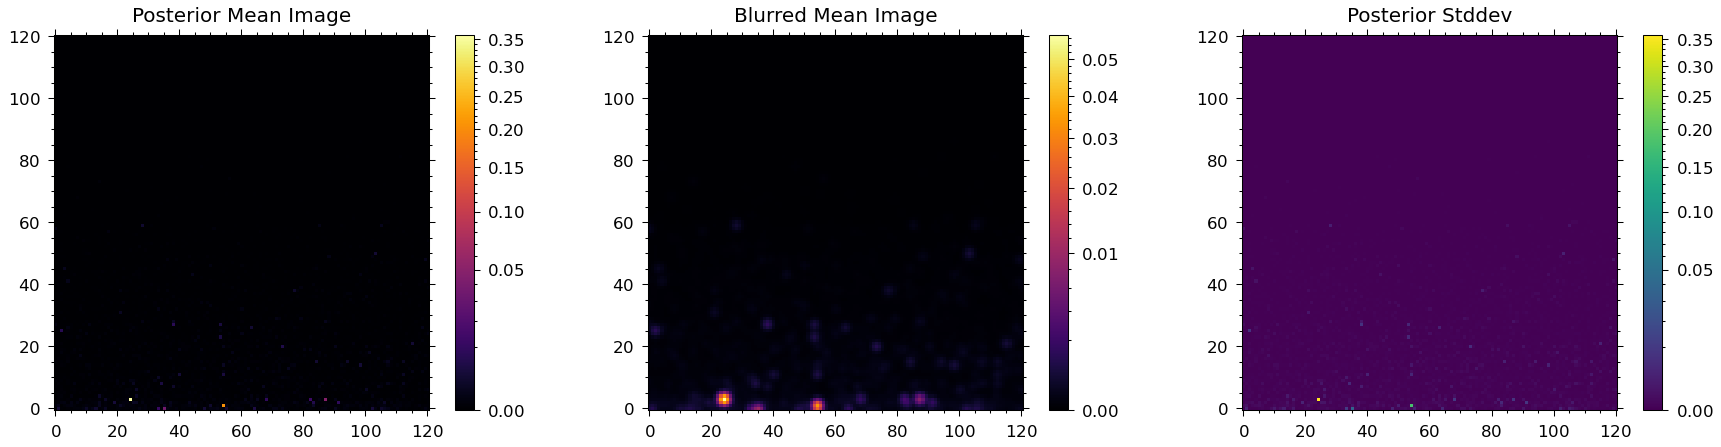

In [ ]:
# # Calculate mean and stddev across the chain
# # dists = constrain_fn(states.position)["dist"].reshape((-1, size, size))
# dists = np.array(
#     [constrain_fn({"dist": chain.T})["dist"] for chain in total_iter]
# ).reshape((-1, size, size))
# mean_image = dists.mean(axis=0).reshape((size, size))
# std_image = dists.std(axis=0).reshape((size, size))

# # Plot side-by-side
# fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# # Posterior Mean
# im0 = axes[0].imshow(
#     mean_image,
#     inferno,
#     norm=mpl.colors.PowerNorm(0.5),
# )
# axes[0].set_title("Posterior Mean Image")
# fig.colorbar(im0, ax=axes[0])

# # Posterior Stddev
# im1 = axes[1].imshow(
#     gaussian_filter(mean_image, sigma=1),
#     inferno,
#     norm=mpl.colors.PowerNorm(0.5),
# )
# axes[1].set_title("Blurred Mean Image")
# fig.colorbar(im1, ax=axes[1])

# # SNR
# im1 = axes[2].imshow(
#     std_image,
#     origin="lower",
#     cmap="viridis",
#     norm=mpl.colors.PowerNorm(0.5),
# )
# axes[2].set_title("Posterior Stddev")
# fig.colorbar(im1, ax=axes[2])

# plt.tight_layout()
# plt.show()